<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [ ]:
!pip install pandas
!pip install pandas 


In [1]:
!pip install matplotlib
!pip install matlplotlib 

ERROR: Could not find a version that satisfies the requirement matlplotlib (from versions: none)
ERROR: No matching distribution found for matlplotlib


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd 
import matplotlib.pyplot as plt 

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [3]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

print(df.head())

file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(file_path)

print(df.head()) 

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [4]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [5]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

print("Original Dataset Shape:")
print(df.shape)

duplicates = df[df.duplicated()]

print("\nDuplicate Rows:\n")
print(duplicates)

print("\nTotal Duplicate Rows:")
print(duplicates.shape[0])

df_cleaned = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df_cleaned.shape)

print("\nRemaining Duplicate Rows:")
print(df_cleaned.duplicated().sum())

Original Dataset Shape:
(65447, 114)

Duplicate Rows:

       ResponseId                                         MainBranch  \
65437           1                     I am a developer by profession   
65438           2                     I am a developer by profession   
65439           3                     I am a developer by profession   
65440           4                              I am learning to code   
65441           5                     I am a developer by profession   
65442           6                        I code primarily as a hobby   
65443           7  I am not primarily a developer, but I write co...   
65444           8                              I am learning to code   
65445           9                        I code primarily as a hobby   
65446          10                     I am a developer by profession   

                      Age                                         Employment  \
65437  Under 18 years old                                Employed, full-

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [6]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

missing_codingactivities = df['CodingActivities'].isnull().sum()

print("Number of missing values in 'CodingActivities' column:")
print(missing_codingactivities)

Number of missing values in 'CodingActivities' column:
10975


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [8]:
import pandas as pd
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

print("Missing values before forward-fill:")
print(df['CodingActivities'].isnull().sum())

df['CodingActivities'] = df['CodingActivities'].ffill()

print("\nMissing values after forward-fill:")
print(df['CodingActivities'].isnull().sum())

print("\nUpdated CodingActivities column:")
print(df[['CodingActivities']].head(10))

Missing values before forward-fill:
10975

Missing values after forward-fill:
0

Updated CodingActivities column:
                                    CodingActivities
0                                              Hobby
1  Hobby;Contribute to open-source projects;Other...
2  Hobby;Contribute to open-source projects;Other...
3  Hobby;Contribute to open-source projects;Other...
4  Hobby;Contribute to open-source projects;Other...
5  Hobby;Contribute to open-source projects;Other...
6                       I don’t code outside of work
7                       I don’t code outside of work
8                                              Hobby
9                           Bootstrapping a business


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [9]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

compensation_columns = [
    col for col in df.columns
    if 'Comp' in col or 'Salary' in col or 'Pay' in col
]

print("Compensation-Related Columns:\n")
print(compensation_columns)

Compensation-Related Columns:

['CompTotal', 'AIComplex', 'ConvertedCompYearly']


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [12]:

import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(url)

df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()


min_salary = df_clean['ConvertedCompYearly'].min()
max_salary = df_clean['ConvertedCompYearly'].max()

df_clean['Normalized_Compensation'] = (
    (df_clean['ConvertedCompYearly'] - min_salary)
    / (max_salary - min_salary)
)

print("Normalized Compensation Values:\n")

print(df_clean[
    ['ConvertedCompYearly', 'Normalized_Compensation']
].head(10))

Normalized Compensation Values:

     ConvertedCompYearly  Normalized_Compensation
72                7322.0                 0.000450
374              30074.0                 0.001850
379              91295.0                 0.005616
385              53703.0                 0.003303
389             110000.0                 0.006766
392             161044.0                 0.009906
395             121018.0                 0.007444
398             195000.0                 0.011995
403              44586.0                 0.002743
409              57999.0                 0.003568


##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [13]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(url)

df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

mean_salary = df_clean['ConvertedCompYearly'].mean()
std_salary = df_clean['ConvertedCompYearly'].std()

df_clean['Zscore_Compensation'] = (
    (df_clean['ConvertedCompYearly'] - mean_salary)
    / std_salary
)

print("Z-score Normalized Values:\n")

print(df_clean[
    ['ConvertedCompYearly', 'Zscore_Compensation']
].head(10))

Z-score Normalized Values:

     ConvertedCompYearly  Zscore_Compensation
72                7322.0            -0.422117
374              30074.0            -0.300290
379              91295.0             0.027521
385              53703.0            -0.173767
389             110000.0             0.127678
392             161044.0             0.400996
395             121018.0             0.186674
398             195000.0             0.582815
403              44586.0            -0.222585
409              57999.0            -0.150764


### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


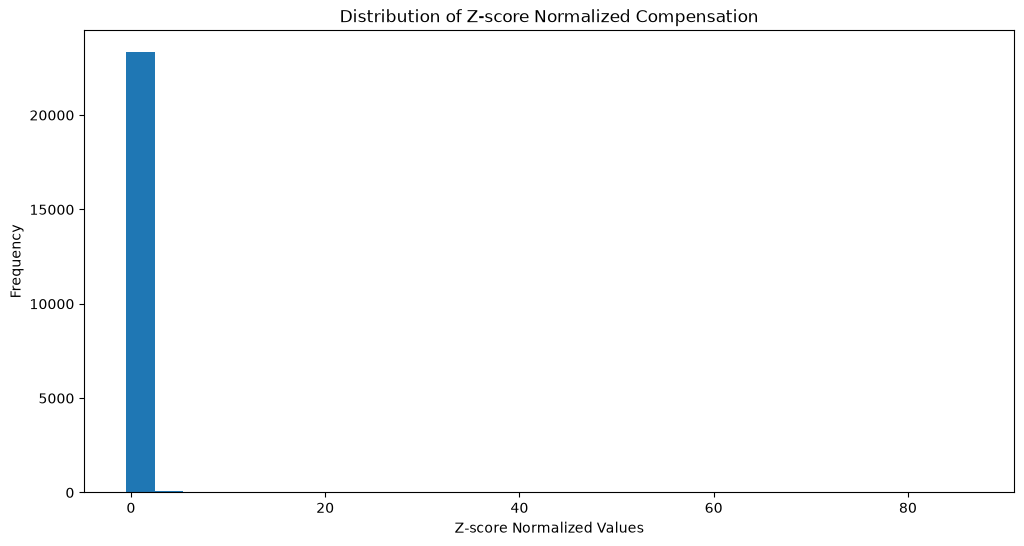

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

mean_salary = df_clean['ConvertedCompYearly'].mean()
std_salary = df_clean['ConvertedCompYearly'].std()

df_clean['Zscore_Compensation'] = (
    (df_clean['ConvertedCompYearly'] - mean_salary)
    / std_salary
)

plt.figure(figsize=(12,6))

plt.hist(df_clean['Zscore_Compensation'], bins=30)

plt.title("Distribution of Z-score Normalized Compensation")
plt.xlabel("Z-score Normalized Values")
plt.ylabel("Frequency")


plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
